## **Peramalan Kadar NO2 di Daerah Sumenep**

### Latar Belakang
Peningkatan aktivitas industri, transportasi, serta pertumbuhan populasi yang pesat telah menyebabkan peningkatan signifikan terhadap tingkat pencemaran udara di berbagai wilayah. Salah satu polutan udara utama yang menjadi perhatian adalah Nitrogen Dioksida (NO₂), yaitu gas beracun yang dihasilkan terutama dari proses pembakaran bahan bakar fosil seperti kendaraan bermotor, pembangkit listrik, dan kegiatan industri. NO₂ memiliki dampak serius terhadap kesehatan manusia, seperti gangguan pernapasan, iritasi paru-paru, serta memperburuk penyakit asma dan bronkitis. Selain itu, NO₂ juga berkontribusi terhadap pembentukan hujan asam dan penurunan kualitas lingkungan secara keseluruhan.

### 1. Pengumpulan Data

Pertama kita akan mengumpulkan data Time Series Harian kadar NO2 di daerah Bangkalan. Pengumpulan data dari sumber website https://dataspace.copernicus.eu/ , buat akun terlebih dahulu di website copernicus tersebut.


Dokumentasi cara pengambilan data di https://documentation.dataspace.copernicus.eu/notebook-samples/openeo/NO2Covid.html .



Untuk menuliskan code Python untuk mengambil data, silahkan kunjungi halaman https://dataspace.copernicus.eu/analyse/jupyterlab, klik Access JupyterLab, scroll kebawah sedikit …, lalu pilih Python 3 (ipykernel)


### 2. Instalasi Library OpenEO

Pada tahap ini dilakukan instalasi library OpenEO yang digunakan untuk mengakses dan mengambil data penginderaan jauh dari Copernicus Data Space Ecosystem. Library ini memungkinkan pengguna untuk melakukan pemrosesan data satelit secara langsung melalui layanan cloud.

In [9]:
!pip install openeo

### 3. Koneksi ke Copernicus Data Space dan Pengambilan Data

Tahap ini bertujuan untuk menghubungkan Python dengan layanan Copernicus Data Space. Setelah koneksi berhasil dilakukan, ditentukan Area of Interest (AOI) berupa wilayah Jombang menggunakan koordinat geografis.

Data yang digunakan berasal dari satelit Sentinel-5P dengan parameter Nitrogen Dioxide (NO₂). Selanjutnya dilakukan proses pengunduhan data dan penyimpanan ke dalam format NetCDF (.nc) untuk dianalisis lebih lanjut.

In [10]:
import openeo
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=GWIM-NLIK 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


In [11]:
aoi = {
    "type": "Polygon",

    "coordinates": [
        [
            [113.7393608, -6.9664964],
            [113.9108166, -6.9658665],
            [113.9026602, -7.0601733],
            [113.7386148, -7.0585753],
            [113.7393608, -6.9664964]
        ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2023-10-01", "2025-10-01"],
    spatial_extent={
        "west": 112.68,
        "south": -7.20,
        "east": 113.09,
        "north": -6.89
    },
    bands=["NO2"],
)

# Now aggregate by day to avoid having multiple data per day
s5p_no2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Now create a spatial aggregation to generate mean timeseries data
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

In [12]:
job = s5post.execute_batch(title="NO2 in Sumenep", outputfile="NO2inSumenep.nc")

0:00:00 Job 'j-2606030740444d85b9956e26c8ba8080': send 'start'
0:00:07 Job 'j-2606030740444d85b9956e26c8ba8080': queued (progress 0%)
0:00:13 Job 'j-2606030740444d85b9956e26c8ba8080': queued (progress 0%)
0:00:20 Job 'j-2606030740444d85b9956e26c8ba8080': queued (progress 0%)
0:00:28 Job 'j-2606030740444d85b9956e26c8ba8080': running (progress N/A)
0:00:38 Job 'j-2606030740444d85b9956e26c8ba8080': running (progress N/A)
0:00:51 Job 'j-2606030740444d85b9956e26c8ba8080': running (progress N/A)
0:01:06 Job 'j-2606030740444d85b9956e26c8ba8080': running (progress N/A)
0:01:26 Job 'j-2606030740444d85b9956e26c8ba8080': running (progress N/A)
0:01:50 Job 'j-2606030740444d85b9956e26c8ba8080': running (progress N/A)
0:02:20 Job 'j-2606030740444d85b9956e26c8ba8080': running (progress N/A)
0:02:58 Job 'j-2606030740444d85b9956e26c8ba8080': running (progress N/A)
0:03:44 Job 'j-2606030740444d85b9956e26c8ba8080': running (progress N/A)
0:04:43 Job 'j-2606030740444d85b9956e26c8ba8080': running (progress

### 4. Instalasi Library NetCDF4

Data hasil unduhan dari Copernicus tersimpan dalam format NetCDF (.nc). Oleh karena itu diperlukan library NetCDF4 agar file dapat dibaca dan diproses menggunakan Python.

In [74]:
!pip install netCDF4

### 5. Membaca Data NO₂ dari File NetCDF

Pada tahap ini file NetCDF dibuka menggunakan library NetCDF4. Selanjutnya dilakukan identifikasi variabel yang tersedia pada dataset, pengambilan data NO₂, serta konversi data waktu menjadi format tanggal agar lebih mudah dianalisis.

In [14]:
import netCDF4
import os

print("File di folder saat ini:")
print(os.listdir())
file_path = "/content/NO2inSumenep.nc"
ds = netCDF4.Dataset(file_path)

# Lihat seluruh variabel yang tersedia
print("📦 Variabel dalam file:")
print(ds.variables.keys())
# dict_keys(['t', 'x', 'y', 'crs', 'NO2'])

# Ambil NO2
no2 = ds.variables["NO2"][:]

# Ambil Time
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal jika punya atribut 'units'
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback kalau tidak ada units

# Tampilkan struktur data NO2
print(type(no2))
# type <class 'numpy.ma.core.MaskedArray'>

print(len(no2))
# banyaknya data record NO2 725

print(len(no2[0]))
# panjang data perbaris 9

print(len(no2[0][0]))
# panjang perdata 8

print(no2[0][0][0])
# 3.7701793e-05

File di folder saat ini:
['.config', 'NO2inSumenep.nc', 'sample_data']
📦 Variabel dalam file:
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])
<class 'numpy.ma.MaskedArray'>
725
9
8
3.7701793e-05


### 6. Menampilkan Contoh Data

Tahap ini digunakan untuk memastikan bahwa data berhasil dibaca dengan benar. Beberapa nilai awal ditampilkan sebagai proses validasi sebelum dilakukan pengolahan lebih lanjut.

In [15]:
print("Contoh data pertama:")
for i in range(0, 10):
    print(no2[i])

Contoh data pertama:
[[3.770179318962619e-05 4.4227883336134255e-05 2.893842975026928e-05
  2.7030169803765602e-05 2.3806940589565784e-05 2.586452137620654e-05
  1.6022562704165466e-05 9.385486009705346e-06]
 [3.770179318962619e-05 3.1096213206183165e-05 3.226231274311431e-05
  2.7030169803765602e-05 2.2647607693215832e-05 3.680306326714344e-05
  1.6022562704165466e-05 3.747334631043486e-05]
 [2.7158148441230878e-05 3.1096213206183165e-05 4.294700556783937e-05
  2.0787138055311516e-05 2.2647607693215832e-05 3.6170044040773064e-05
  2.544464950915426e-05 2.3946160581544973e-05]
 [2.9651806471520104e-05 3.772687341552228e-05 4.294700556783937e-05
  5.6563803809694946e-05 4.394538700580597e-05 3.6170044040773064e-05
  6.348737952066585e-05 3.904499681084417e-05]
 [2.9651806471520104e-05 4.1052295273402706e-05 -- 5.6563803809694946e-05
  -- -- 6.348737952066585e-05 --]
 [3.303916673758067e-05 4.1052295273402706e-05 1.2694688848569058e-05 --
  -- -- -- --]
 [1.5709914805484004e-05 3.2586256

### 7. Pengolahan Data Harian NO₂

Data NO₂ yang diperoleh masih berbentuk array multidimensi. Oleh karena itu dilakukan proses perhitungan rata-rata untuk setiap tanggal sehingga diperoleh satu nilai NO₂ harian yang mewakili kondisi udara pada hari tersebut.

Hasil pengolahan kemudian disimpan ke dalam DataFrame yang terdiri dari kolom tanggal dan nilai NO₂.

In [16]:
import numpy as np
import pandas as pd

# Interpolasi Linear
no2_filled = np.zeros_like(no2)
# Untuk jaga-jaga jika terdapat '--' tidak berubah menjadi 0
no2_filled = no2_filled.filled(0)

# loop tiap grid (y,x)
for i in range(no2.shape[1]):     # 9 baris
    for j in range(no2.shape[2]): # 8 kolom
        series = pd.Series(no2[:, i, j])
        no2_filled[:, i, j] = series.interpolate(method='linear', limit_direction='both').to_numpy()

In [17]:
new_dates = []
new_no2 = []
for i in range(len(dates)):
    # ubah format datetime
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)
    new_no2.append(np.mean(no2_filled[i]))

In [52]:
df = pd.DataFrame({
    "date": dates,
    "NO2": new_no2
})

# Simpan ke CSV
df.to_csv("NO2_Sumenep_timeseries.csv", index=False)
print(df.head())

                  date       NO2
0  2023-10-01 00:00:00  0.000027
1  2023-10-02 00:00:00  0.000024
2  2023-10-03 00:00:00  0.000024
3  2023-10-04 00:00:00  0.000021
4  2023-10-05 00:00:00  0.000021


### 8. Pemeriksaan Kelengkapan Data Tanggal

Tahap ini bertujuan untuk memeriksa apakah terdapat tanggal yang hilang pada rentang waktu pengamatan. Pemeriksaan dilakukan dengan membandingkan tanggal yang tersedia pada dataset dengan rentang tanggal lengkap.

In [49]:
import pandas as pd
import numpy as np

df = pd.read_csv("NO2_Sumenep_timeseries.csv")

# Pastikan kolom 'date' bertipe datetime
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2023-10-01"
end_date = "2025-09-30"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 6
Daftar tanggal missing:
DatetimeIndex(['2023-11-11', '2024-01-01', '2024-03-23', '2024-08-12',
               '2025-01-30', '2025-01-31'],
              dtype='datetime64[ns]', freq=None)


### 9. Interpolasi Missing Date

Apabila ditemukan tanggal yang hilang, maka dilakukan interpolasi berdasarkan urutan waktu. Teknik ini digunakan untuk mengisi nilai yang kosong sehingga data time series menjadi kontinu dan siap digunakan pada tahap pemodelan.

In [50]:
import pandas as pd

# Pastikan datetime dan sorting
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# Buat rentang tanggal lengkap
full_range = pd.date_range(start="2023-10-01", end="2025-09-30", freq='D')

# Reindex agar tanggal yang hilang muncul sebagai NaN
df = df.set_index('date').reindex(full_range)
df.index.name = 'date'

# Interpolasi linear berdasarkan indeks waktu
df['NO2'] = df['NO2'].interpolate(method='time')

# (Opsional) jika masih ada NaN di bagian awal/akhir bisa gunakan forward/backward fill
df['NO2'] = df['NO2'].fillna(method='bfill').fillna(method='ffill')

# Simpan kembali ke CSV
df.to_csv("no2_timeseries_interpolated.csv")

/tmp/ipykernel_5516/2413223189.py:18: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['NO2'] = df['NO2'].fillna(method='bfill').fillna(method='ffill')


In [27]:
import pandas as pd
import numpy as np

df = pd.read_csv("no2_timeseries_interpolated.csv")

# Pastikan kolom 'date' bertipe datetime
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2023-10-01"
end_date = "2025-09-30"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 0
Daftar tanggal missing:
DatetimeIndex([], dtype='datetime64[ns]', freq='D')


In [28]:
import pandas as pd

# Kalau date masih kolom
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date')
    df = df.set_index('date')
else:
    df.index = pd.to_datetime(df.index)

full_range = pd.date_range(start="2023-06-03", end="2026-06-03", freq='D')

df = df.reindex(full_range)
df.index.name = 'date'

df['NO2'] = df['NO2'].interpolate(method='time')
df['NO2'] = df['NO2'].bfill().ffill()

# Biar bentuknya jadi 2 kolom seperti tutorial: date dan NO2
df = df.reset_index()

df.to_csv("no2_timeseries_interpolated.csv", index=False)

print(df.head())
print(df.info())

        date       NO2
0 2023-06-03  0.000027
1 2023-06-04  0.000027
2 2023-06-05  0.000027
3 2023-06-06  0.000027
4 2023-06-07  0.000027
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1097 entries, 0 to 1096
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    1097 non-null   datetime64[ns]
 1   NO2     1097 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 17.3 KB
None


### 10. Deteksi Outlier Menggunakan Metode IQR

Outlier merupakan nilai yang berada jauh di luar pola umum data. Pada penelitian ini digunakan metode Interquartile Range (IQR) untuk menentukan batas bawah dan batas atas data normal.

Nilai yang berada di luar rentang tersebut akan ditandai sebagai outlier.

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("no2_timeseries_interpolated.csv")

df['date'] = pd.to_datetime(df['date'])

# Hitung IQR
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'NO2']].head())


Jumlah Outlier (IQR): 14
         date       NO2
45 2023-11-15  0.000051
46 2023-11-16  0.000044
48 2023-11-18  0.000051
67 2023-12-07  0.000047
68 2023-12-08  0.000045


### 11. Visualisasi Hasil Deteksi Outlier

Grafik berikut digunakan untuk melihat distribusi data NO₂ serta posisi outlier yang terdeteksi. Visualisasi ini membantu dalam memahami kualitas data sebelum dilakukan proses pembersihan.

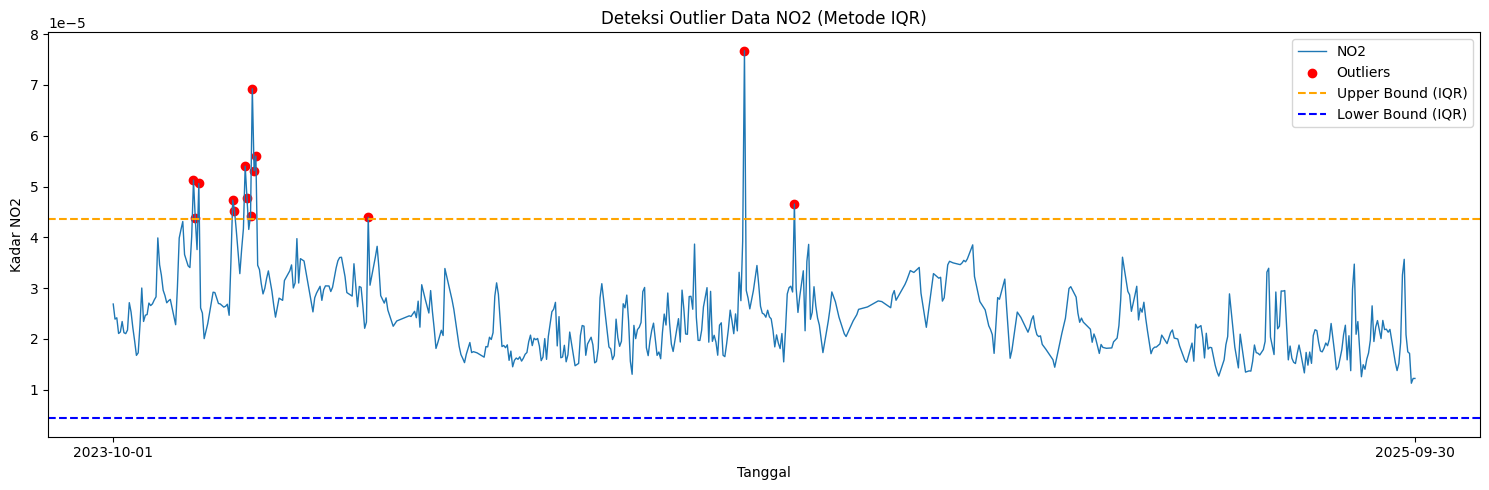

In [55]:
# === Visualisasi ===
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)

# Titik Outlier
plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'],
            color='red', marker='o', label="Outliers")

# Garis batas atas & bawah
plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue', linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data NO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

### 12. Penanganan Outlier

Outlier yang terdeteksi tidak langsung dihapus, tetapi diubah menjadi nilai kosong (NaN). Selanjutnya nilai tersebut diisi kembali menggunakan interpolasi linear sehingga pola data tetap terjaga dan tidak menyebabkan kehilangan informasi.

In [56]:
# Tandai outlier menjadi NaN
df['NO2_cleaned'] = df['NO2'].mask((df['NO2'] < lower_bound) | (df['NO2'] > upper_bound))

print("Jumlah nilai yang dinyatakan sebagai outlier:", df['NO2_cleaned'].isna().sum())

# Interpolasi linear untuk mengisi kembali nilai outlier
df['NO2_filled'] = df['NO2_cleaned'].interpolate(method='linear')

# Jika masih tersisa NaN di ujung data, isi dengan forward/backward fill
df['NO2_filled'] = df['NO2_filled'].bfill().ffill()
# df['NO2_filled'] = df['NO2_filled'].fillna(method='bfill').fillna(method='ffill')

print("Jumlah missing setelah interpolasi:", df['NO2_filled'].isna().sum())

Jumlah nilai yang dinyatakan sebagai outlier: 14
Jumlah missing setelah interpolasi: 0


### 13. Visualisasi Data Setelah Interpolasi

Setelah proses pembersihan data selesai dilakukan, grafik kembali ditampilkan untuk memastikan bahwa outlier telah berhasil ditangani dan pola data menjadi lebih stabil.

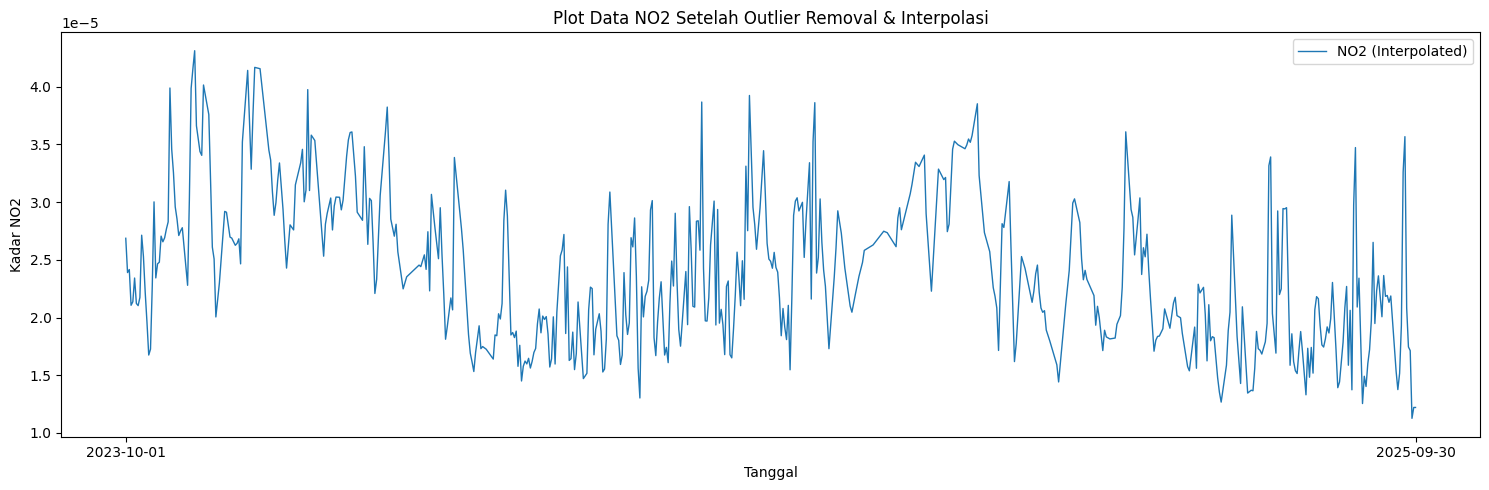

In [57]:
plt.figure(figsize=(15,5))
# Plot data hasil interpolasi
plt.plot(df['date'], df['NO2_filled'], label="NO2 (Interpolated)", linewidth=1)
# Tampilkan hanya tanggal awal dan akhir di sumbu X
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.title("Plot Data NO2 Setelah Outlier Removal & Interpolasi")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.show()

### 14. Analisis Korelasi Data Time Series

Tahap ini digunakan untuk mengetahui hubungan antara data NO₂ pada periode sebelumnya dengan nilai NO₂ pada periode saat ini. Analisis korelasi membantu menentukan jumlah lag yang layak digunakan dalam proses peramalan.

In [60]:
import pandas as pd

def create_supervised(data, n_lag=4):
    df_supervised = pd.DataFrame()

    # Membuat fitur t-4 sampai t-1
    for i in range(n_lag, 0, -1):
        df_supervised[f'NO2(t-{i})'] = data.shift(i)

    # Label hari H
    df_supervised['NO2(t)'] = data

    # Hapus baris yang masih mengandung NaN akibat shift
    df_supervised.dropna(inplace=True)

    return df_supervised

# contoh penggunaan
supervised_df30 = create_supervised(df['NO2_scaled'], n_lag=30)

# Ambil semua lag dan kolom target
lag_cols = supervised_df30.drop(columns="NO2(t)").columns
correlations = supervised_df30[lag_cols].corrwith(supervised_df30['NO2(t)'])

# Tampilkan nilai korelasi
print(correlations)

NO2(t-30)    0.477867
NO2(t-29)    0.502708
NO2(t-28)    0.498987
NO2(t-27)    0.472795
NO2(t-26)    0.439887
NO2(t-25)    0.422289
NO2(t-24)    0.402892
NO2(t-23)    0.408835
NO2(t-22)    0.420553
NO2(t-21)    0.420595
NO2(t-20)    0.406650
NO2(t-19)    0.390524
NO2(t-18)    0.379138
NO2(t-17)    0.359376
NO2(t-16)    0.366913
NO2(t-15)    0.372538
NO2(t-14)    0.383520
NO2(t-13)    0.389351
NO2(t-12)    0.398411
NO2(t-11)    0.420611
NO2(t-10)    0.446750
NO2(t-9)     0.469323
NO2(t-8)     0.490583
NO2(t-7)     0.496860
NO2(t-6)     0.503654
NO2(t-5)     0.526012
NO2(t-4)     0.566348
NO2(t-3)     0.643091
NO2(t-2)     0.736752
NO2(t-1)     0.855116
dtype: float64


### 15. Normalisasi Data Menggunakan Min-Max Scaling

Normalisasi dilakukan untuk mengubah rentang nilai data menjadi 0 hingga 1. Langkah ini penting karena metode KNN menggunakan perhitungan jarak, sehingga seluruh fitur perlu berada pada skala yang sama.

In [63]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

scaler = MinMaxScaler()

df['NO2_scaled'] = scaler.fit_transform(df[['NO2']])

### 16. Pembentukan Dataset Supervised Learning (Lag 4 Hari & 10 Hari)

Data time series diubah menjadi bentuk supervised learning dengan menggunakan 4 hari atau 10 Hari sebelumnya sebagai fitur untuk memprediksi nilai NO₂ pada hari berikutnya.

In [65]:
supervised_df = create_supervised(df['NO2_scaled'], n_lag=4)

print(supervised_df)
print(supervised_df.shape)

     NO2(t-4)  NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)
4    0.238203  0.192840  0.196854  0.149560  0.154247
5    0.192840  0.196854  0.149560  0.154247  0.185625
6    0.196854  0.149560  0.154247  0.185625  0.152010
7    0.149560  0.154247  0.185625  0.152010  0.149143
8    0.154247  0.185625  0.152010  0.149143  0.159907
..        ...       ...       ...       ...       ...
726  0.123092  0.325742  0.372653  0.145997  0.094458
727  0.325742  0.372653  0.145997  0.094458  0.089599
728  0.372653  0.145997  0.094458  0.089599  0.000000
729  0.145997  0.094458  0.089599  0.000000  0.014405
730  0.094458  0.089599  0.000000  0.014405  0.014405

[727 rows x 5 columns]
(727, 5)


In [66]:
supervised_df10 = create_supervised(df['NO2_scaled'], n_lag=10)

print(supervised_df10)
print(supervised_df10.shape)

     NO2(t-10)  NO2(t-9)  NO2(t-8)  NO2(t-7)  NO2(t-6)  NO2(t-5)  NO2(t-4)  \
10    0.238203  0.192840  0.196854  0.149560  0.154247  0.185625  0.152010   
11    0.192840  0.196854  0.149560  0.154247  0.185625  0.152010  0.149143   
12    0.196854  0.149560  0.154247  0.185625  0.152010  0.149143  0.159907   
13    0.149560  0.154247  0.185625  0.152010  0.149143  0.159907  0.242292   
14    0.154247  0.185625  0.152010  0.149143  0.159907  0.242292  0.214105   
..         ...       ...       ...       ...       ...       ...       ...   
726   0.161874  0.128849  0.095824  0.062799  0.038033  0.059606  0.123092   
727   0.128849  0.095824  0.062799  0.038033  0.059606  0.123092  0.325742   
728   0.095824  0.062799  0.038033  0.059606  0.123092  0.325742  0.372653   
729   0.062799  0.038033  0.059606  0.123092  0.325742  0.372653  0.145997   
730   0.038033  0.059606  0.123092  0.325742  0.372653  0.145997  0.094458   

     NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)  
10   0.149143  0.

In [67]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def MAPE(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Hindari pembagian dengan nol
    nonzero = y_true != 0
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

def train_knn(df_supervised, model_name=""):
    # Pisahkan fitur & label
    X = df_supervised.drop(columns=['NO2(t)']).values
    y = df_supervised['NO2(t)'].values

    # Split data 80/20
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    # Model KNN
    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train, y_train)

    # Prediksi
    y_pred = knn.predict(X_test)

    # Evaluasi
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = MAPE(y_test, y_pred)

    print(f"\n=== {model_name} ===")
    print(f"Train Size: {len(X_train)} — Test Size: {len(X_test)}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAPE: {mape:.4f}%")

    return knn, y_test, y_pred


# Train model untuk 4 hari sebelumnya
knn_4, y_test_4, y_pred_4 = train_knn(supervised_df, "KNN - 4 Hari Sebelumnya")

# Train model untuk 10 hari sebelumnya
knn_10, y_test_10, y_pred_10 = train_knn(supervised_df10, "KNN - 10 Hari Sebelumnya")


=== KNN - 4 Hari Sebelumnya ===
Train Size: 581 — Test Size: 146
RMSE: 0.065457
R² Score: 0.1399
MAPE: 61.0796%

=== KNN - 10 Hari Sebelumnya ===
Train Size: 576 — Test Size: 145
RMSE: 0.067596
R² Score: 0.0888
MAPE: 64.6647%


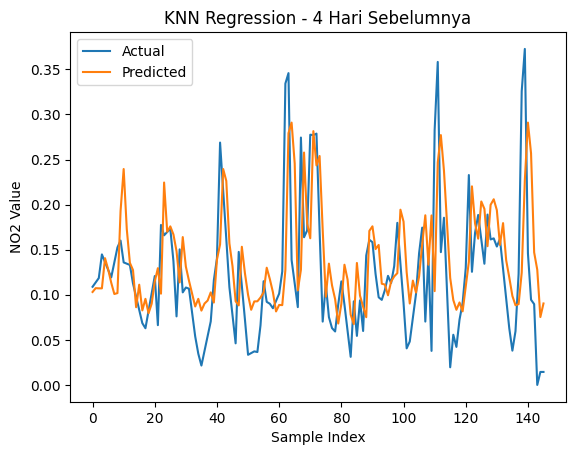

In [68]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.plot(np.arange(len(y_test_4)), y_test_4, label="Actual")
plt.plot(np.arange(len(y_pred_4)), y_pred_4, label="Predicted")
plt.title("KNN Regression - 4 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

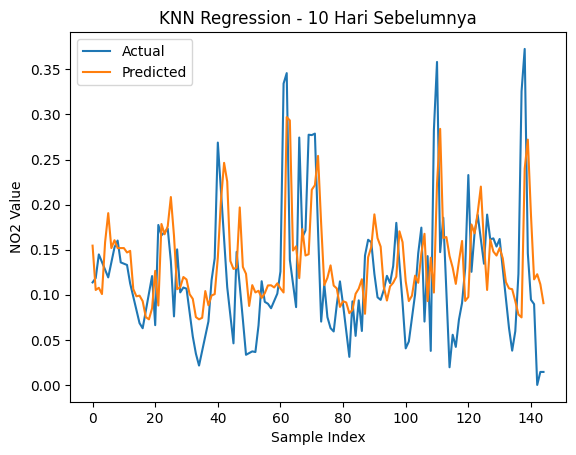

In [69]:
plt.figure()
plt.plot(np.arange(len(y_test_10)), y_test_10, label="Actual")
plt.plot(np.arange(len(y_pred_10)), y_pred_10, label="Predicted")
plt.title("KNN Regression - 10 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

### 17. Pembentukan Dataset Supervised Learning (Lag 2 Hari)

Data time series diubah menjadi bentuk supervised learning dengan menggunakan 2 hari sebelumnya sebagai fitur untuk memprediksi nilai NO₂ pada hari berikutnya.

In [71]:
supervised_df_2_day_lag = create_supervised(df['NO2_scaled'], n_lag=2)

print(supervised_df_2_day_lag)
print(supervised_df_2_day_lag.shape)

     NO2(t-2)  NO2(t-1)    NO2(t)
2    0.238203  0.192840  0.196854
3    0.192840  0.196854  0.149560
4    0.196854  0.149560  0.154247
5    0.149560  0.154247  0.185625
6    0.154247  0.185625  0.152010
..        ...       ...       ...
726  0.372653  0.145997  0.094458
727  0.145997  0.094458  0.089599
728  0.094458  0.089599  0.000000
729  0.089599  0.000000  0.014405
730  0.000000  0.014405  0.014405

[729 rows x 3 columns]
(729, 3)


In [72]:
# Train model untuk 2 hari sebelumnya
knn_2, y_test_2, y_pred_2 = train_knn(supervised_df_2_day_lag, "KNN - 2 Hari Sebelumnya")


=== KNN - 2 Hari Sebelumnya ===
Train Size: 583 — Test Size: 146
RMSE: 0.066154
R² Score: 0.1214
MAPE: 62.8850%


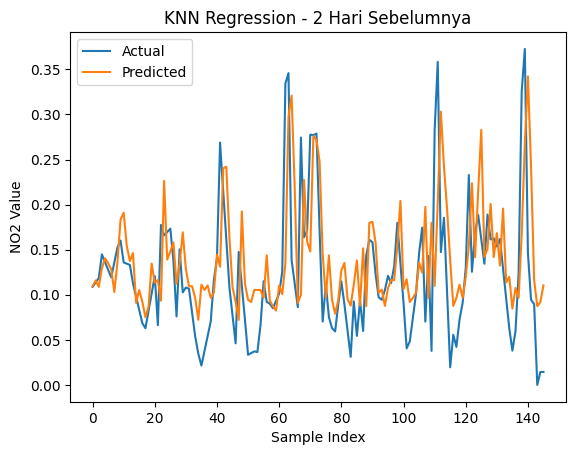

In [73]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.plot(np.arange(len(y_test_2)), y_test_2, label="Actual")
plt.plot(np.arange(len(y_pred_2)), y_pred_2, label="Predicted")
plt.title("KNN Regression - 2 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

### Kesimpulan

Berdasarkan hasil peramalan kadar NO₂ di wilayah Jombang menggunakan metode KNN Regression, dapat disimpulkan bahwa model mampu mempelajari pola historis data dan menghasilkan prediksi terhadap nilai NO₂ pada periode berikutnya.

Pengujian dilakukan menggunakan tiga skenario lag, yaitu 4 hari, 10 hari, dan 30 hari sebelumnya. Performa model dievaluasi menggunakan RMSE, R² Score, dan MAPE. Hasil evaluasi menunjukkan bahwa jumlah lag yang digunakan berpengaruh terhadap kualitas prediksi yang dihasilkan.

Visualisasi antara nilai aktual dan nilai prediksi menunjukkan bahwa model mampu mengikuti pola umum pergerakan data NO₂ meskipun masih terdapat beberapa deviasi pada titik-titik tertentu. Oleh karena itu, metode KNN Regression dapat digunakan sebagai salah satu pendekatan untuk peramalan kualitas udara berbasis data time series.